# Лекция 3. Разбор упражнений

Упражнения из раздела 14 конспекта [`lecture03.md`](lecture03.md). Каждое разбирается по одной схеме:

1. **условие**;
2. **решение по шагам** — вручную, как на лекции;
3. **проверка кодом** — тот же вывод получаем численно.

Сначала попробуйте решить сами. Краткие ответы без кода — в [`exercises03.md`](exercises03.md); как считать двойственную функцию в коде — в [`demo03.ipynb`](demo03.ipynb).

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})

## 14.1. Одномерная задача $\min x^2$ при $x \geq 2$

> Выпишите $L(x,\mu)$, найдите $d(\mu)$ в явном виде, вычислите $d(0), d(2), d(4)$ и убедитесь, что все они $\le p^\ast$. Найдите $\mu^\ast$ и проверьте $d^\ast=p^\ast$.

**Решение.** $h(x)=x-2\ge0$, $L(x,\mu)=x^2-\mu(x-2)$. Минимум по $x$: $\partial L/\partial x=2x-\mu=0\Rightarrow x(\mu)=\mu/2$. Подставляем:

$$
d(\mu) = \Big(\frac{\mu}{2}\Big)^2 - \mu\Big(\frac{\mu}{2}-2\Big) = -\frac{\mu^2}{4}+2\mu .
$$

$d(0)=0$, $d(2)=3$, $d(4)=4$ — все $\le p^\ast=f(2)=4$, последнее — с равенством. Максимум: $d'(\mu)=-\mu/2+2=0\Rightarrow\mu^\ast=4$, $d(4)=4=p^\ast$. Задача выпукла (парабола, аффинное неравенство), Слейтер выполнен ($x=3$ строго допустима) — сильная двойственность гарантирована теоремой раздела 7, что мы и наблюдаем.

mu=0: d(mu) = 0.0  (<= p* = 4.0? True)
mu=2: d(mu) = 3.0  (<= p* = 4.0? True)
mu=4: d(mu) = 4.0  (<= p* = 4.0? True)

mu* = 4.000000014999999  d* = 4.0  p* = 4.0


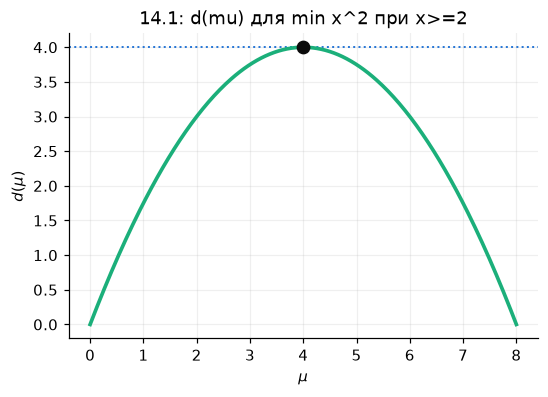

In [2]:
f = lambda x: x ** 2
d_formula = lambda mu: -mu ** 2 / 4 + 2 * mu
pstar = f(2.0)

for mu in (0, 2, 4):
    print(f"mu={mu}: d(mu) = {d_formula(mu)}  (<= p* = {pstar}? {d_formula(mu) <= pstar + 1e-9})")

res = minimize(lambda mu: -d_formula(mu[0]), x0=[0.0], bounds=[(0, None)])
print("\nmu* =", res.x[0], " d* =", -res.fun, " p* =", pstar)

mu_grid = np.linspace(0, 8, 300)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.axhline(pstar, color=BLUE, ls=":", lw=1.3)
ax.plot(mu_grid, d_formula(mu_grid), color=AQUA, lw=2.4)
ax.plot(4, 4, "o", color=INK, ms=8)
ax.set(xlabel="$\\mu$", ylabel="$d(\\mu)$", title="14.1: d(mu) для min x^2 при x>=2")
plt.show()

## 14.2. LP планирования производства: где ломается теневая цена

> Увеличьте мощность третьего цеха с $18$ до $b_3$. Найдите значение $b_3$, при котором набор активных ограничений меняется, и новые теневые цены сразу после этой точки. Почему теневая цена ограничения 3 обязана обратиться в ноль ровно там, где оно перестаёт быть активным?

**Решение.** Пока активны ограничения 2 ($2x_2\le12$) и 3 ($3x_1+2x_2\le18$), решение — их пересечение: $x_2=6$, $x_1=(b_3-12)/3$. Это движение по ребру продолжается, пока $x_1$ не упрётся в своё же ограничение $x_1\le4$, то есть пока $(b_3-12)/3\le4 \Leftrightarrow b_3\le24$. При $b_3=24$ решение — вершина $(4,6)$, где **одновременно** активны ограничения 1 и 2, а ограничение 3 перестаёт быть узким местом: дальнейшее увеличение $b_3$ ничего не меняет, оно больше не активно, и по комплементарной нежёсткости ($\mu_3^\ast h_3(x^\ast)=0$ при $h_3>0$) обязано быть $\mu_3^\ast=0$. Сразу после точки перелома ($b_3>24$) активны ограничения 1 и 2: решая систему $x_1=4$, $2x_2=12$, теневые цены находятся из $A^\top y=c$ на активных строках: $y_1\cdot1+y_2\cdot0=3$, $y_1\cdot0+y_2\cdot2=5\Rightarrow y=(3,\,2.5,\,0)$.

In [3]:
A = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]])
c = np.array([3.0, 5.0])

for b3 in (20, 23, 24, 25, 28):
    r = linprog(-c, A_ub=A, b_ub=[4.0, 12.0, b3], bounds=[(0, None)] * 2, method="highs")
    y = -r.ineqlin.marginals
    print(f"b3={b3:5.1f}: x*={r.x.round(3)}, прибыль={-r.fun:.3f}, y*={y.round(3)}")

b3= 20.0: x*=[2.667 6.   ], прибыль=38.000, y*=[0.  1.5 1. ]
b3= 23.0: x*=[3.667 6.   ], прибыль=41.000, y*=[0.  1.5 1. ]
b3= 24.0: x*=[4. 6.], прибыль=42.000, y*=[3.  2.5 0. ]
b3= 25.0: x*=[4. 6.], прибыль=42.000, y*=[3.  2.5 0. ]
b3= 28.0: x*=[4. 6.], прибыль=42.000, y*=[3.  2.5 0. ]


## 14.3. Двойственность QP на новом ящике

> $Q=\begin{pmatrix}1&0.8\\0.8&2\end{pmatrix}$, $c=(1,-2)$, $-1\le x\le1$. Решите численно, максимизируйте $d(\mu)$ по четырём $\mu\ge0$ и проверьте $d^\ast=f^\ast$ и комплементарную нежёсткость. Проверьте баланс сил $\nabla f(x^\ast)=\sum_i\mu_i^\ast\nabla h_i(x^\ast)$.

**Решение.** $Q\succ0$ (собственные числа $\approx0.557,\,2.443$ — проверка кодом ниже), задача — выпуклая QP, Слейтер выполнен (внутренняя точка $(0,0)$) — сильная двойственность гарантирована. В отличие от примера лекции (раздел 9), здесь на решении активны **сразу два** ограничения — хороший повод убедиться, что комплементарная нежёсткость работает и в этом случае покоординатно, независимо для каждого $\mu_i$.

In [4]:
Q = np.array([[1.0, 0.8], [0.8, 2.0]])
c = np.array([1.0, -2.0])
print("собственные числа Q:", np.linalg.eigvalsh(Q).round(4), "-> Q > 0")

fqp = lambda x: 0.5 * x @ Q @ x + c @ x
xstar = minimize(fqp, x0=np.zeros(2), jac=lambda x: Q @ x + c, method="L-BFGS-B",
                  bounds=[(-1, 1), (-1, 1)]).x
print("x* =", xstar.round(4), " f* =", round(fqp(xstar), 6))

Qinv = np.linalg.inv(Q)
def dual_d(mu):
    mu = np.asarray(mu, float)
    shift = np.array([mu[0] - mu[1], mu[2] - mu[3]])
    xun = -Qinv @ (c + shift)
    return 0.5 * xun @ Q @ xun + (c + shift) @ xun - mu.sum(), xun

res = minimize(lambda mu: -dual_d(np.clip(mu, 0, None))[0], x0=np.ones(4), method="Nelder-Mead",
               options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 30_000})
mu_star = np.clip(res.x, 0, None)
dstar, x_from_dual = dual_d(mu_star)
print("mu* =", mu_star.round(4))
print("d* =", round(dstar, 6), " f* =", round(fqp(xstar), 6))
print("x из двойственной =", x_from_dual.round(4), " x* =", xstar.round(4))

h = np.array([1 - xstar[0], 1 + xstar[0], 1 - xstar[1], 1 + xstar[1]])
print("\nh(x*) =", h.round(4), " mu* =", mu_star.round(4))
print("mu_i * h_i(x*) =", (mu_star * h).round(8), "-> все нули: комплементарная нежёсткость выполнена")

# баланс сил (раздел 5.1): grad f = sum mu_i grad h_i, нормали граней h = (1-x1, 1+x1, 1-x2, 1+x2)
grad_h = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]], float)
print("\ngrad f(x*)        =", (Q @ xstar + c).round(4))
print("sum mu_i grad h_i =", (mu_star @ grad_h).round(4), "-> тяга уравновешена двумя активными стенками")

собственные числа Q: [0.5566 2.4434] -> Q > 0
x* = [-1.  1.]  f* = -2.3


mu* = [0.  0.8 0.8 0. ]
d* = -2.3  f* = -2.3
x из двойственной = [-1.  1.]  x* = [-1.  1.]

h(x*) = [2. 0. 0. 2.]  mu* = [0.  0.8 0.8 0. ]
mu_i * h_i(x*) = [0. 0. 0. 0.] -> все нули: комплементарная нежёсткость выполнена

grad f(x*)        = [ 0.8 -0.8]
sum mu_i grad h_i = [ 0.8 -0.8] -> тяга уравновешена двумя активными стенками


## 14.4. Слейтер для аффинных ограничений

> Объясните, почему условие Слейтера для задачи, где все ограничения аффинны, выполняется автоматически, как только допустимое множество непусто. Какой важный факт про LP из этого следует?

**Решение.** Условие Слейтера (раздел 7) требует строгой допустимости **только для нелинейных** $h_i$ — для аффинных $h_i(x)=a_i^\top x-b_i$ достаточно обычного $h_i(\tilde x)\ge0$. В LP **все** ограничения аффинны (и неравенства, и равенства), поэтому у условия Слейтера просто нет содержания сверх «допустимое множество непусто»: любая допустимая точка автоматически строго допустима, потому что для аффинных ограничений это условие вырождается. Отсюда важный факт: **для любой разрешимой LP (с ограниченным оптимумом) зазора двойственности нет никогда** — не нужно ничего проверять отдельно, в отличие от общих выпуклых задач. Это ровно то, что мы молча использовали в разделе 8 конспекта.

Убедимся на примере: возьмём LP планирования производства и намеренно проверим граничную (не строго внутреннюю) допустимую точку — условие Слейтера всё равно должно считаться выполненным, потому что определение просто не предъявляет к ней требований.

In [5]:
# точка на самой границе допустимого множества (x1=4, x2=0) -- вершина, ни одно h_i там не строго > 0
A = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]])
b = np.array([4.0, 12.0, 18.0])
x_corner = np.array([4.0, 0.0])
h_corner = np.r_[b - A @ x_corner, x_corner]
print("h(x) в угловой точке:", h_corner.round(4), " -- нестрого >= 0, и этого достаточно: все h_i аффинны")
print("(для нелинейного h пришлось бы искать точку со СТРОГИМ h_i > 0 -- см. следующее упражнение, 14.5)")

h(x) в угловой точке: [ 0. 12.  6.  4.  0.]  -- нестрого >= 0, и этого достаточно: все h_i аффинны
(для нелинейного h пришлось бы искать точку со СТРОГИМ h_i > 0 -- см. следующее упражнение, 14.5)


## 14.5. Скрытая выпуклость: прямоугольник в круге

> $\min -4x_1x_2$ при $x_1^2+x_2^2=1$, $x_1,x_2\ge0$. Покажите, что $L(x,\lambda)$ при неактивных $x_1,x_2\ge0$ сводится к квадратичной форме с матрицей $\begin{pmatrix}\lambda&-2\\-2&\lambda\end{pmatrix}$, найдите, при каких $\lambda$ она $\succeq0$, вычислите $d(\lambda)$ и $d^\ast$, сравните с $p^\ast=-2$.

**Решение.** Ограничения $x_1,x_2\ge0$ на решении неактивны ($x^\ast=(1/\sqrt2,1/\sqrt2)$ строго внутри квадранта), поэтому их множители нулевые, и остаётся только равенство $g(x)=x_1^2+x_2^2-1=0$ с множителем $\lambda$ любого знака:

$$
L(x,\lambda) = -4x_1x_2 - \lambda(x_1^2+x_2^2-1) = -\lambda x_1^2-4x_1x_2-\lambda x_2^2+\lambda = -x^\top\!\begin{pmatrix}\lambda&2\\2&\lambda\end{pmatrix}\!x+\lambda .
$$

Инфимум по $x\in\mathbb{R}^2$ конечен тогда и только тогда, когда матрица $\begin{pmatrix}\lambda&2\\2&\lambda\end{pmatrix}\succeq0$ (иначе форма неограничена снизу), то есть при $\lambda\ge2$ (собственные числа $\lambda\pm2$); тогда инфимум достигается при $x=0$ и равен просто $\lambda$, а $d(\lambda) = -\lambda$. Максимизируя $-\lambda$ по $\lambda\ge2$, получаем $\lambda^\ast=2$, $d^\ast=-2=p^\ast$ — зазора нет, хотя задача невыпукла (равенство нелинейно, чек-лист лекции 2 не проходит).

Ключевое отличие от примера раздела 6 (тоже невыпуклого, но с бесконечным зазором): там было **несколько линейных** неравенств и цель, не ограниченная снизу ни на каком направлении, — релаксация Лагранжа теряла всё. Здесь — **одно квадратичное** равенство, и оказывается, что для задач вида «квадратичная цель при одном квадратичном ограничении» двойственность точна всегда (результат известен как *S-лемма* / лемма Дайнса); это не общее свойство невыпуклых задач, а частное свойство именно такой структуры.

p* = -2.0  x* = [0.7071 0.7071]  (теория: -2 при (1/sqrt2, 1/sqrt2))


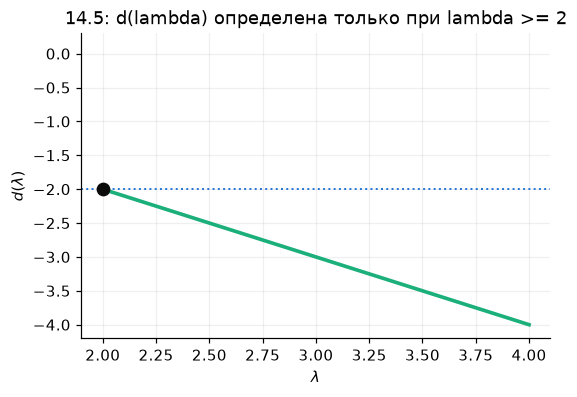


d* = max при lambda=2: -2  = p*: -2.0


In [6]:
f = lambda x: -4 * x[0] * x[1]
res = minimize(f, x0=[0.9, 0.1], bounds=[(0, 1), (0, 1)],
               constraints=[{"type": "eq", "fun": lambda x: x[0] ** 2 + x[1] ** 2 - 1}])
print("p* =", round(res.fun, 6), " x* =", res.x.round(4), " (теория: -2 при (1/sqrt2, 1/sqrt2))")

lams = np.linspace(0, 4, 200)
d_vals = []
for lam in lams:
    eig = np.linalg.eigvalsh(np.array([[lam, 2.0], [2.0, lam]]))
    d_vals.append(-lam if eig.min() >= -1e-9 else np.nan)
d_vals = np.array(d_vals)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(lams, d_vals, color=AQUA, lw=2.4)
ax.axhline(res.fun, color=BLUE, ls=":", lw=1.3)
ax.plot(2, -2, "o", color=INK, ms=8)
ax.set(xlabel="$\\lambda$", ylabel="$d(\\lambda)$", title="14.5: d(lambda) определена только при lambda >= 2",
       ylim=(-4.2, 0.3))
plt.show()
print("\nd* = max при lambda=2:", -2, " = p*:", round(res.fun, 6))

## Что запомнить

- Двойственную функцию можно найти в закрытом виде (14.1, 14.5) или максимизировать численно (14.2, 14.3) — оба пути дают одно и то же $d^\ast$, когда сильная двойственность есть.
- Комплементарная нежёсткость проверяется покоординатно: $\mu_i^\ast h_i(x^\ast)=0$ для *каждого* $i$ по отдельности, и работает одинаково хорошо с одним активным ограничением (лекция) и с несколькими сразу (14.3).
- Для LP условие Слейтера бесплатно (14.4) — зазора не бывает никогда; для QP и общих выпуклых задач его стоит явно проверить (обычно тривиально).
- «Невыпукло» не равно «двойственность бесполезна»: структура ограничения решает (14.5 против примера раздела 6 конспекта) — но полагаться на удачу без проверки нельзя.